# Data Exploration

## Objective

To understand the datasets before changing anything.

To know our data.

# Import Libraries

In [9]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats



# Load Datasets

In [10]:
import pandas as pd

kaggle_df = pd.read_csv("../data/enhanced_menstrual_cycle_dataset.csv")
survey_df = pd.read_csv("../data/participants.csv")

In [11]:
print(kaggle_df.shape)
print(survey_df.shape)

(20000, 33)
(69, 29)


# Missing Value Analysis

In [13]:
def missing_value_analysis(df, dataset_name):
    """
    Display missing value summary and heatmap.
    """

    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing Percentage (%)": (df.isnull().mean() * 100).round(2)
    })

    missing = missing[missing["Missing Count"] > 0].reset_index()
    missing = missing.rename(columns={"index": "Column"})

    print(f"\n{'='*60}")
    print(f"{dataset_name} - Missing Value Summary")
    print(f"{'='*60}")

    if missing.empty:
        print("No missing values found.")
    else:
        missing_display = missing.copy()
        missing_display["Missing Percentage (%)"] = missing_display["Missing Percentage (%)"].map(lambda x: f"{x:.2f}")
        display(missing_display.sort_values("Missing Percentage (%)", ascending=False))

    plt.figure(figsize=(16, 8), dpi=120)
    ax = sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
    plt.title(f"Missing Value Heatmap - {dataset_name}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.subplots_adjust(left=0.04, right=0.98, top=0.95, bottom=0.25)
    plt.show()


# For kaggle dataset


Kaggle Dataset - Missing Value Summary
No missing values found.


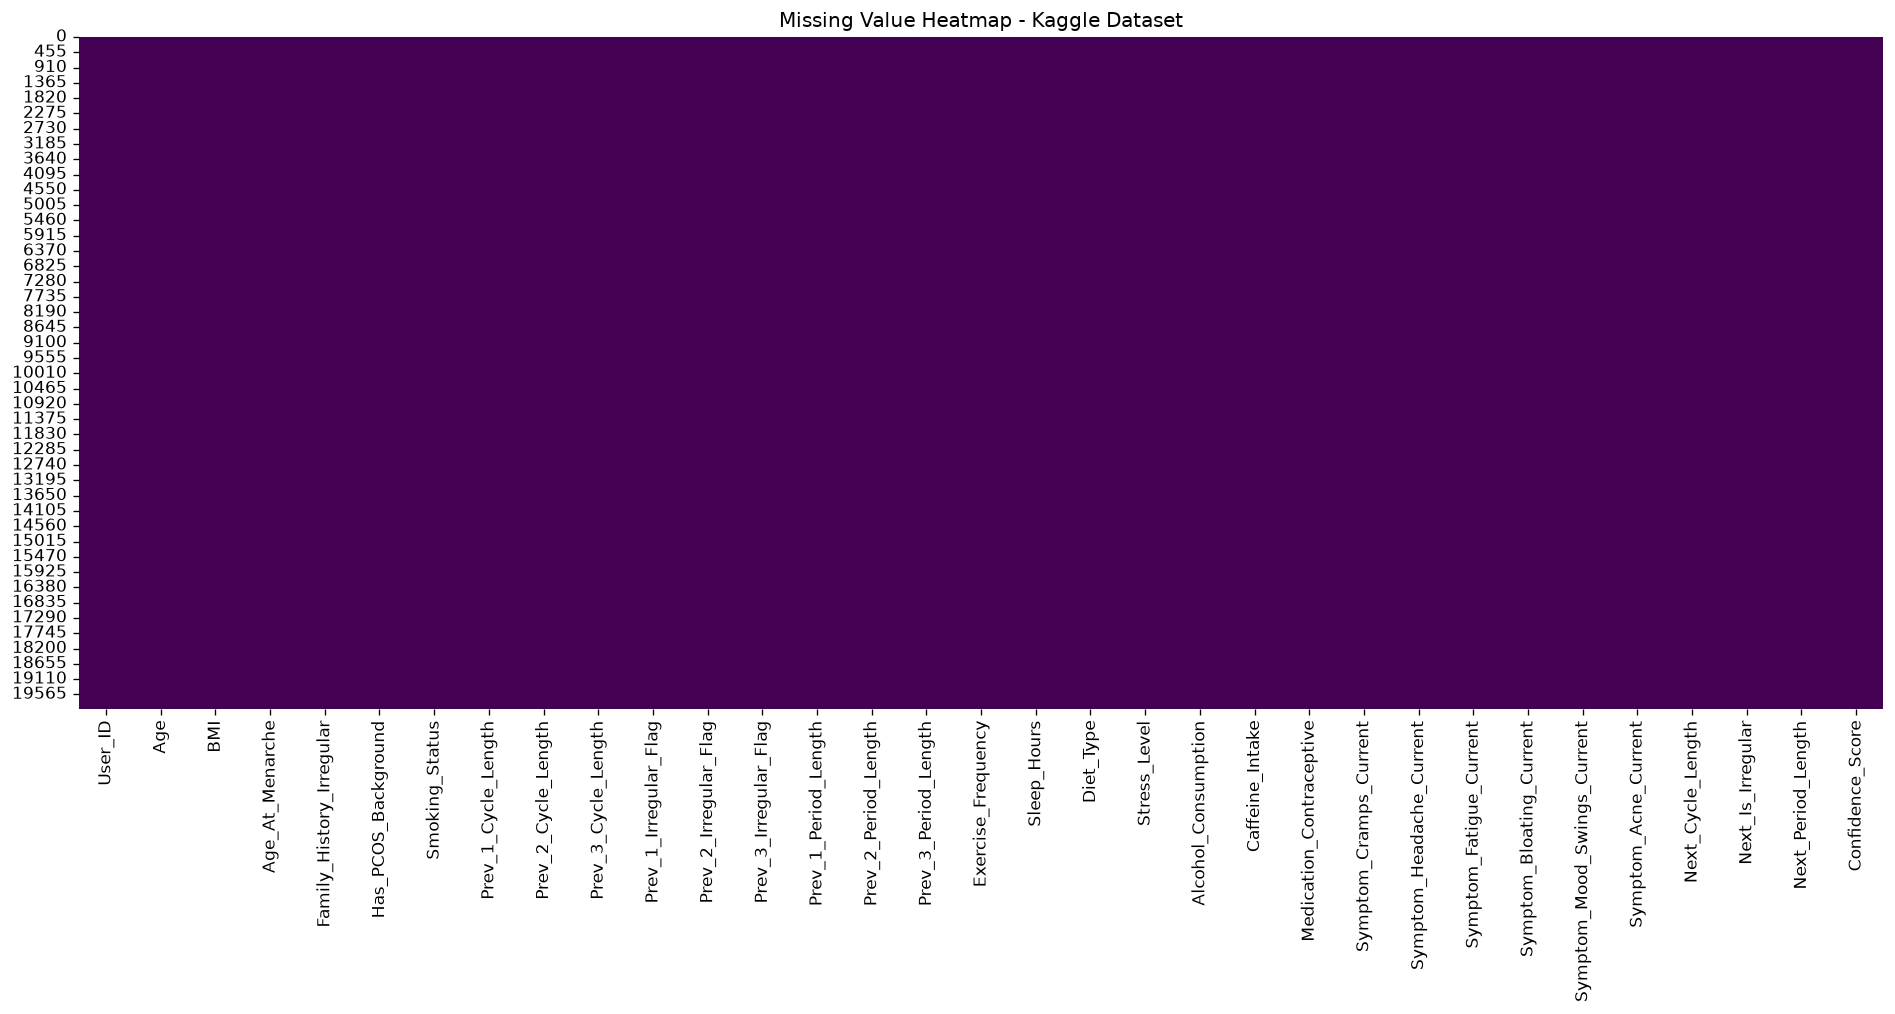

In [14]:
missing_value_analysis(kaggle_df, "Kaggle Dataset")


# For survey



Survey Dataset - Missing Value Summary


,Column,Missing Count,Missing Percentage (%)
11,current_cycle_length,68,98.55
12,current_period_length,68,98.55
13,current_irregular_flag,68,98.55
3,sleep_hours,3,4.35
0,height,2,2.90
2,bmi,2,2.90
1,weight,1,1.45
4,prev2_cycle_length,1,1.45
5,prev3_cycle_length,1,1.45
6,prev1_period_length,1,1.45


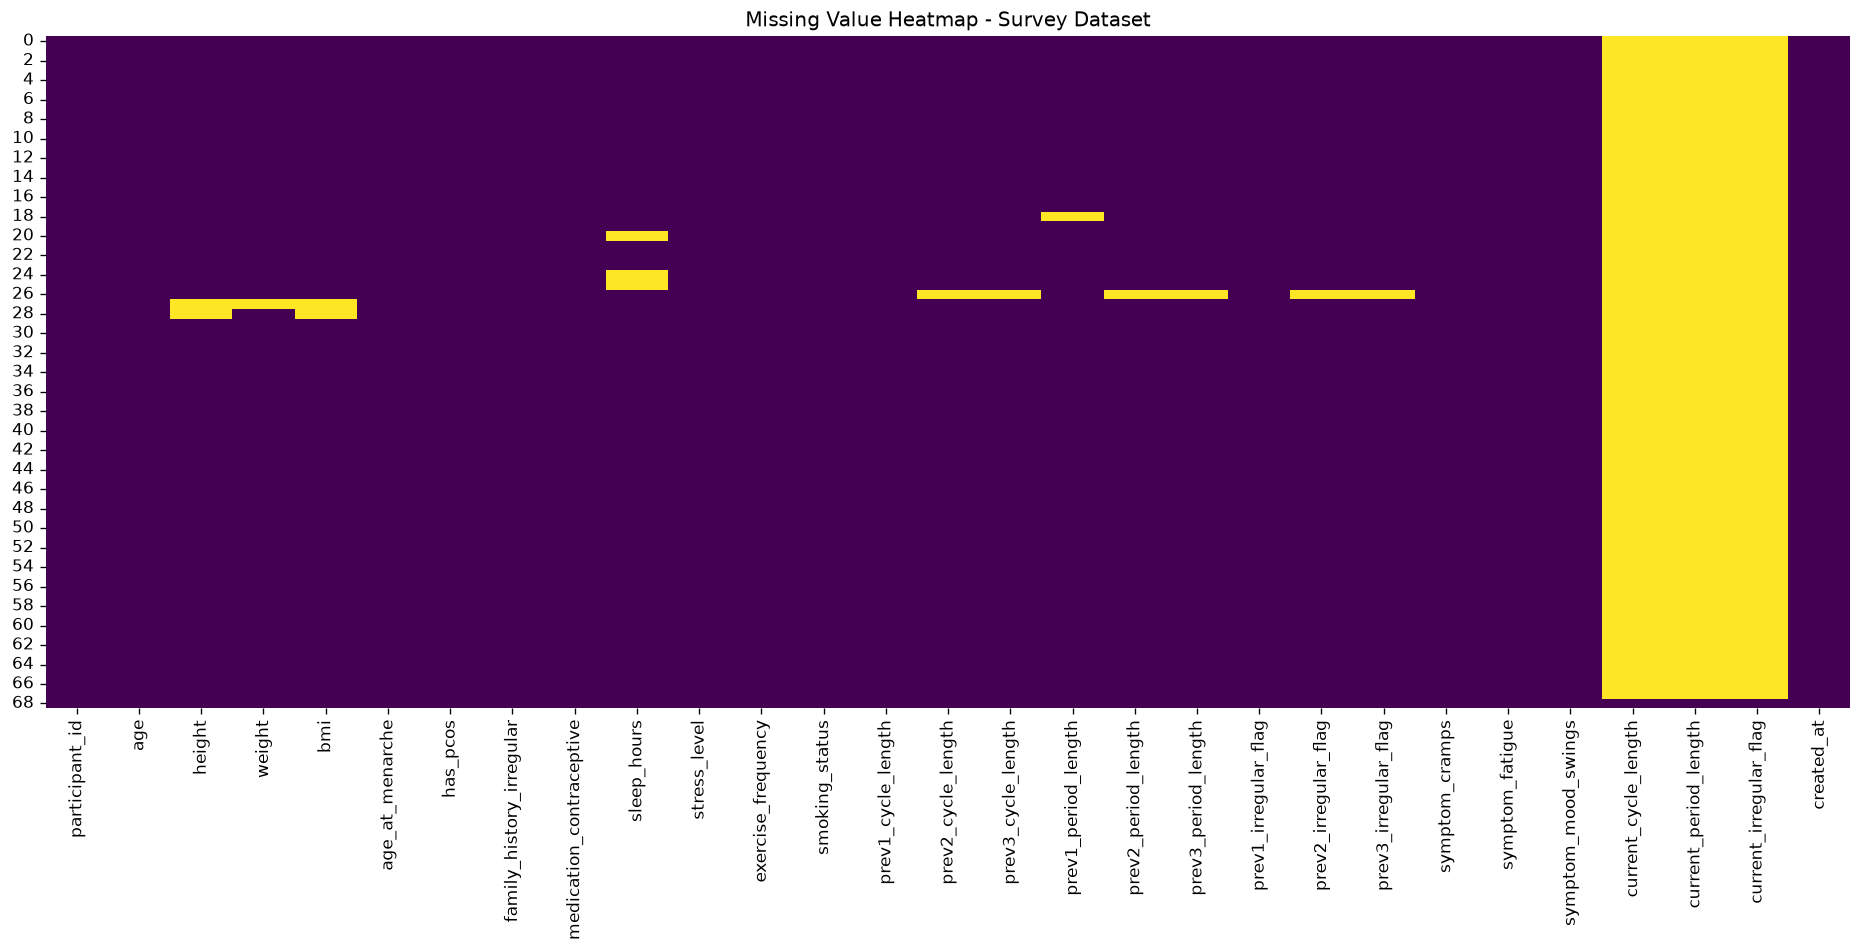

In [15]:
missing_value_analysis(survey_df, "Survey Dataset")

# Duplicate Analysis

In [16]:
def duplicate_analysis(df, dataset_name):

    duplicates = df.duplicated().sum()

    print(f"\n{dataset_name}")
    print("-"*40)
    print(f"Duplicate Rows : {duplicates}")

duplicate_analysis(kaggle_df, "Kaggle Dataset")
duplicate_analysis(survey_df, "Survey Dataset")


Kaggle Dataset
----------------------------------------
Duplicate Rows : 0

Survey Dataset
----------------------------------------
Duplicate Rows : 0


# Dataset Shape

In [17]:
def dataset_shape(df, dataset_name):

    print(f"\n{dataset_name}")
    print("-"*40)

    print(f"Rows    : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

dataset_shape(kaggle_df, "Kaggle Dataset")
dataset_shape(survey_df, "Survey Dataset")


Kaggle Dataset
----------------------------------------
Rows    : 20000
Columns : 33

Survey Dataset
----------------------------------------
Rows    : 69
Columns : 29


# Data Types

In [18]:
def data_types(df, dataset_name):

    print(f"\n{dataset_name}")
    print("-"*40)

    display(df.dtypes.to_frame(name="Data Type"))

data_types(kaggle_df, "Kaggle Dataset")
data_types(survey_df, "Survey Dataset")


Kaggle Dataset
----------------------------------------


,Data Type
User_ID,int64
Age,int64
BMI,float64
Age_At_Menarche,int64
Family_History_Irregular,int64
Has_PCOS_Background,int64
Smoking_Status,int64
Prev_1_Cycle_Length,int64
Prev_2_Cycle_Length,int64
Prev_3_Cycle_Length,int64



Survey Dataset
----------------------------------------


,Data Type
participant_id,str
age,int64
height,float64
weight,float64
bmi,float64
age_at_menarche,int64
has_pcos,str
family_history_irregular,str
medication_contraceptive,str
sleep_hours,float64


## 7. Descriptive Statistics

Descriptive statistics summarize the central tendency and variability of the dataset. This analysis helps identify the range, distribution, and potential anomalies in both numerical and categorical features before preprocessing.

In [19]:
def descriptive_statistics(df, dataset_name):
    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    print("\nNumerical Features")
    display(df.describe().T)

    categorical_cols = df.select_dtypes(include=["object", "category"]).columns

    if len(categorical_cols) > 0:
        print("\nCategorical Features")
        display(df[categorical_cols].describe().T)
    else:
        print("\nNo categorical features found.")

In [20]:
descriptive_statistics(kaggle_df, "Kaggle Dataset")
descriptive_statistics(survey_df, "Survey Dataset")

Kaggle Dataset

Numerical Features


,count,mean,std,min,25%,50%,75%,max
User_ID,20000.0,500.500000,288.682207,1.0,250.75,500.50,750.25,1000.00
Age,20000.0,30.799000,7.924502,18.0,24.00,30.50,38.00,45.00
BMI,20000.0,26.769200,4.841137,18.5,22.50,26.65,31.20,35.00
Age_At_Menarche,20000.0,12.490000,2.309582,9.0,10.00,12.00,14.00,16.00
Family_History_Irregular,20000.0,0.208000,0.405887,0.0,0.00,0.00,0.00,1.00
Has_PCOS_Background,20000.0,0.094000,0.291836,0.0,0.00,0.00,0.00,1.00
Smoking_Status,20000.0,0.151000,0.358058,0.0,0.00,0.00,0.00,1.00
Prev_1_Cycle_Length,20000.0,30.456650,8.392064,0.0,29.00,31.00,33.00,90.00
Prev_2_Cycle_Length,20000.0,28.853600,10.647584,0.0,28.00,31.00,33.00,90.00
Prev_3_Cycle_Length,20000.0,27.240450,12.287355,0.0,28.00,30.00,33.00,90.00



No categorical features found.
Survey Dataset

Numerical Features


,count,mean,std,min,25%,50%,75%,max
age,69.0,25.434783,6.607657,16.0,21.00,24.00,27.0,45.0
height,67.0,9.734925,25.781487,4.1,5.00,5.30,5.5,161.0
weight,68.0,56.227941,9.372647,35.0,50.00,56.50,62.0,80.0
bmi,67.0,21.944776,3.193995,15.7,19.85,22.30,24.0,29.3
age_at_menarche,69.0,12.826087,1.349908,9.0,12.00,13.00,14.0,16.0
sleep_hours,66.0,6.159091,2.208653,0.0,6.00,6.75,7.5,9.0
prev1_cycle_length,69.0,29.289855,3.325930,18.0,28.00,29.00,30.0,39.0
prev2_cycle_length,68.0,29.514706,3.559694,23.0,28.00,29.00,30.0,45.0
prev3_cycle_length,68.0,29.441176,3.739193,22.0,28.00,29.00,30.0,40.0
prev1_period_length,68.0,4.838235,1.101021,2.0,4.00,5.00,5.0,7.0



Categorical Features


,count,unique,top,freq
participant_id,69,69,4a80e858-b8c9-48e1-8b4e-1ba0ada808a9,1
has_pcos,69,3,No,41
family_history_irregular,69,3,No,41
medication_contraceptive,69,3,No,55
stress_level,69,5,Moderate,40
exercise_frequency,69,4,1-2 days/week,28
smoking_status,69,2,No,56
prev2_irregular_flag,68,2,False,64
prev3_irregular_flag,68,2,False,61
current_irregular_flag,1,1,False,1


## 8. Feature Type Identification

Machine learning algorithms require different preprocessing techniques depending on the type of each feature. Therefore, the features are categorized into numerical, categorical, binary, ordinal, and identifier variables. This classification guides later preprocessing steps such as scaling, encoding, and feature selection.

In [21]:
def identify_feature_types(df, dataset_name):

    numerical = []
    categorical = []
    binary = []
    identifier = []

    for col in df.columns:

        # Identifier columns
        if "id" in col.lower():
            identifier.append(col)

        # Numeric columns
        elif pd.api.types.is_numeric_dtype(df[col]):

            if df[col].nunique() == 2:
                binary.append(col)
            else:
                numerical.append(col)

        # Object columns
        else:

            if df[col].nunique() == 2:
                binary.append(col)
            else:
                categorical.append(col)

    print("=" * 70)
    print(dataset_name)
    print("=" * 70)

    print("\nNumerical Features")
    print(numerical)

    print("\nBinary Features")
    print(binary)

    print("\nCategorical Features")
    print(categorical)

    print("\nIdentifier Columns")
    print(identifier if identifier else "None")

In [22]:
identify_feature_types(kaggle_df, "Kaggle Dataset")
identify_feature_types(survey_df, "Survey Dataset")

Kaggle Dataset

Numerical Features
['Age', 'BMI', 'Age_At_Menarche', 'Prev_1_Cycle_Length', 'Prev_2_Cycle_Length', 'Prev_3_Cycle_Length', 'Prev_1_Period_Length', 'Prev_2_Period_Length', 'Prev_3_Period_Length', 'Exercise_Frequency', 'Sleep_Hours', 'Diet_Type', 'Stress_Level', 'Alcohol_Consumption', 'Caffeine_Intake', 'Next_Cycle_Length', 'Next_Period_Length']

Binary Features
['Family_History_Irregular', 'Has_PCOS_Background', 'Smoking_Status', 'Prev_1_Irregular_Flag', 'Prev_2_Irregular_Flag', 'Prev_3_Irregular_Flag', 'Medication_Contraceptive', 'Symptom_Cramps_Current', 'Symptom_Headache_Current', 'Symptom_Fatigue_Current', 'Symptom_Bloating_Current', 'Symptom_Mood_Swings_Current', 'Symptom_Acne_Current', 'Next_Is_Irregular']

Categorical Features
[]

Identifier Columns
['User_ID', 'Confidence_Score']
Survey Dataset

Numerical Features
['age', 'height', 'weight', 'bmi', 'age_at_menarche', 'sleep_hours', 'prev1_cycle_length', 'prev2_cycle_length', 'prev3_cycle_length', 'prev1_period_len

## 9. Target Variable Analysis (Kaggle Dataset)

The Kaggle dataset contains the target variables `next_cycle_length` and `next_period_length`, which are the prediction targets for this regression project.

The survey dataset does not contain these target variables because it represents user-provided input data that will be used during inference in the mobile application rather than for supervised model training.

Therefore, target variable analysis is performed only on the Kaggle dataset.

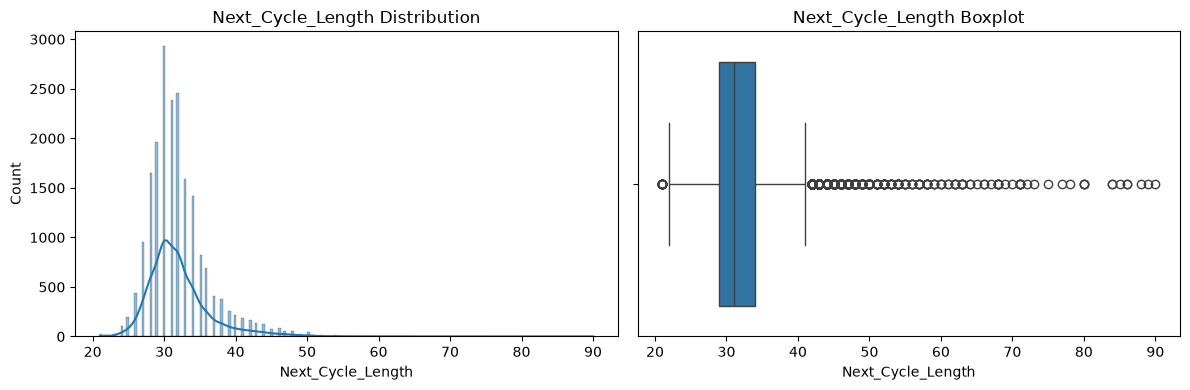


Summary Statistics for Next_Cycle_Length


count    20000.000000
mean        32.065400
std          4.736681
min         21.000000
25%         29.000000
50%         31.000000
75%         34.000000
max         90.000000
Name: Next_Cycle_Length, dtype: float64

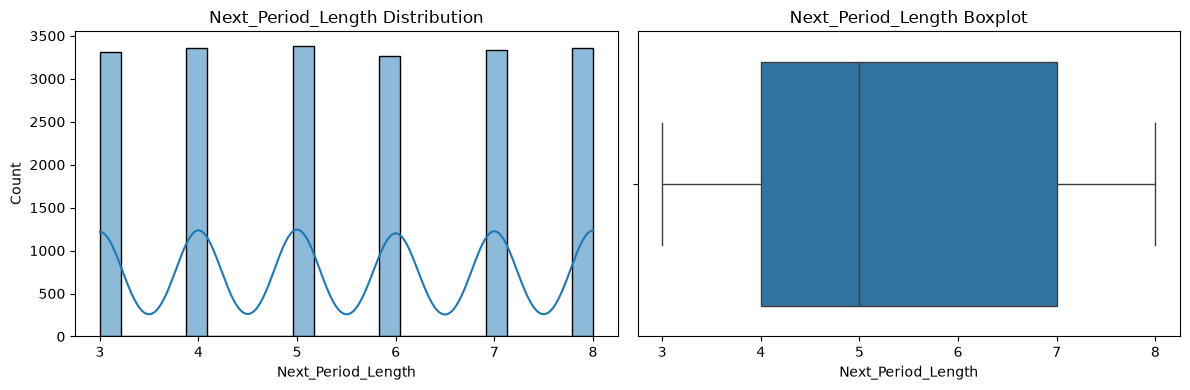


Summary Statistics for Next_Period_Length


count    20000.000000
mean         5.500350
std          1.708287
min          3.000000
25%          4.000000
50%          5.000000
75%          7.000000
max          8.000000
Name: Next_Period_Length, dtype: float64

In [23]:
def find_target_column(df, target_name):
    if target_name in df.columns:
        return target_name

    normalized = {col.lower(): col for col in df.columns}
    if target_name.lower() in normalized:
        return normalized[target_name.lower()]

    return None

for target_name in ["Next_Cycle_Length", "Next_Period_Length"]:
    target = find_target_column(kaggle_df, target_name)

    if target is None:
        print(f"Column '{target_name}' not found in the Kaggle dataset.")
        continue

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(kaggle_df[target], kde=True)
    plt.title(f"{target} Distribution")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=kaggle_df[target])
    plt.title(f"{target} Boxplot")

    plt.tight_layout()
    plt.show()

    print(f"\nSummary Statistics for {target}")
    display(kaggle_df[target].describe())


## 10. Correlation Analysis

Correlation analysis measures the strength and direction of linear relationships between numerical variables.

For this project, correlation analysis is performed only on the Kaggle dataset because it contains the target variables (`next_cycle_length` and `next_period_length`). The results help identify highly correlated features, potential multicollinearity, and informative predictors for model development.

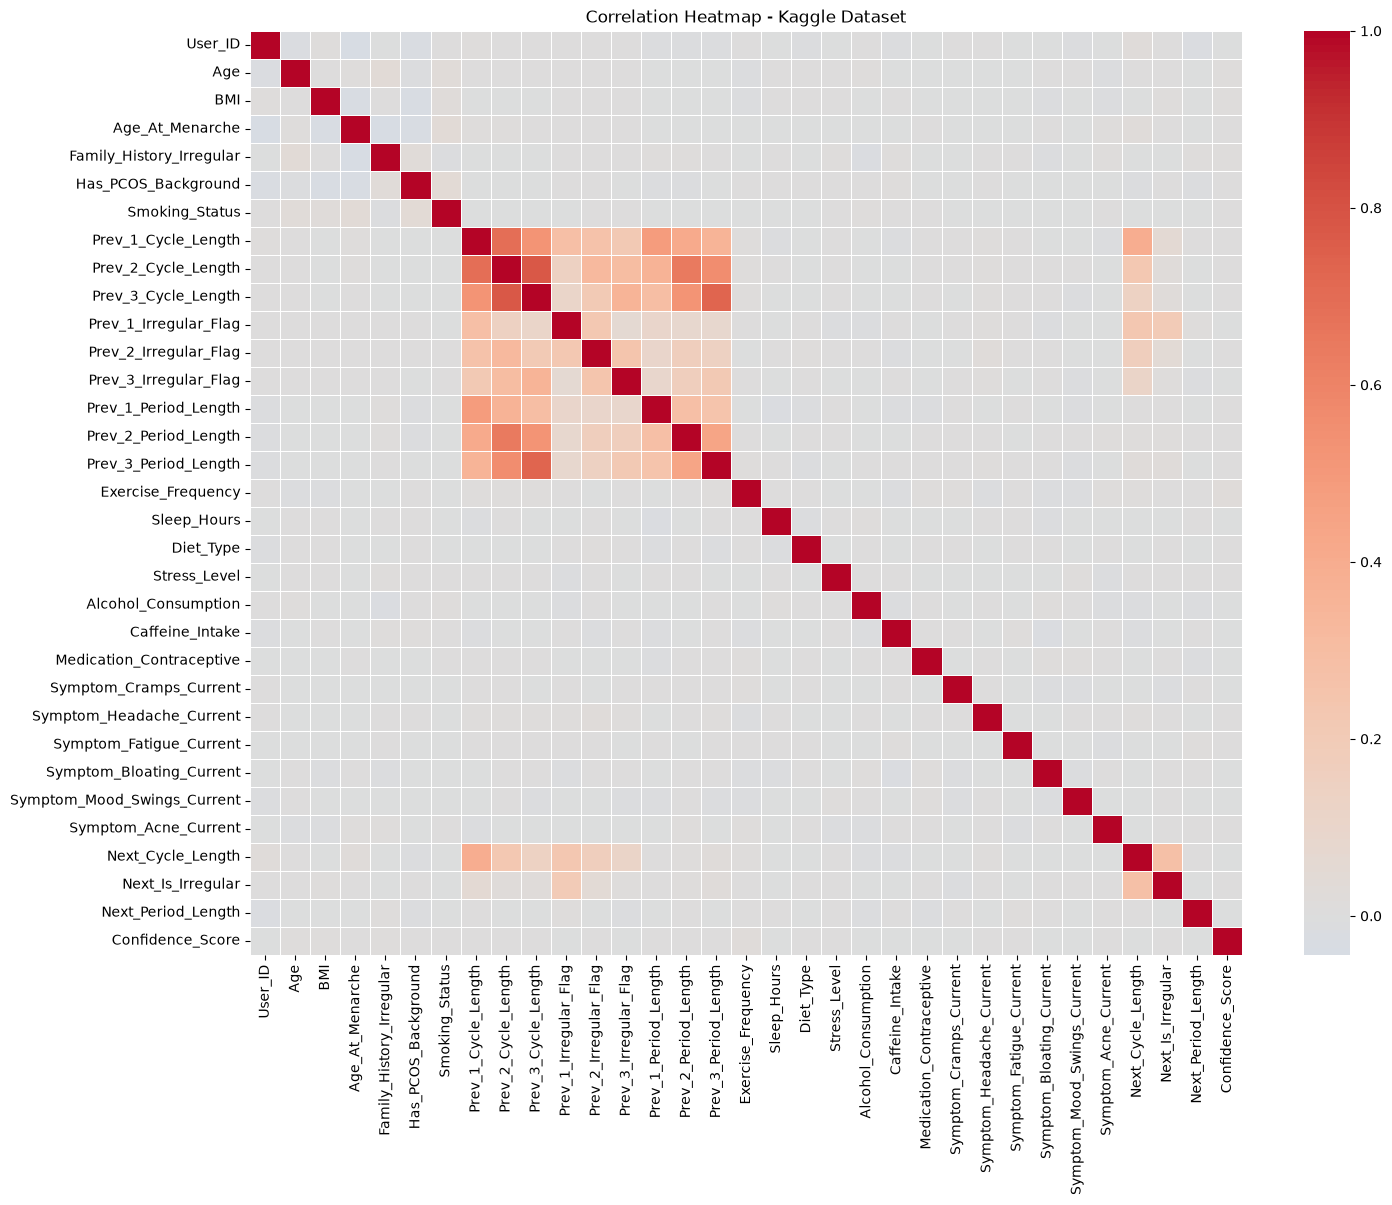

In [24]:
# Select only numerical columns
numeric_df = kaggle_df.select_dtypes(include=["number"])

# Correlation matrix
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap - Kaggle Dataset")

plt.show()

# Correlation with Target Variables

In [33]:
def find_target_column(df, target_name):
    if target_name in df.columns:
        return target_name

    normalized = {col.lower(): col for col in df.columns}
    if target_name.lower() in normalized:
        return normalized[target_name.lower()]

    return None

for target_name in ["Next_Cycle_Length"]:
    target = find_target_column(kaggle_df, target_name)

    if target is None:
        print(f"Column '{target_name}' not found in the Kaggle dataset.")
        continue

    print(f"\nCorrelation with {target}")

    display(
        correlation_matrix[target]
        .sort_values(ascending=False)
        .to_frame("Correlation")
    )



Correlation with Next_Cycle_Length


,Correlation
Next_Cycle_Length,1.000000
Prev_1_Cycle_Length,0.396832
Next_Is_Irregular,0.274150
Prev_1_Irregular_Flag,0.230837
Prev_2_Cycle_Length,0.223067
Prev_2_Irregular_Flag,0.168603
Prev_3_Cycle_Length,0.140442
Prev_3_Irregular_Flag,0.114060
Age_At_Menarche,0.023302
User_ID,0.017567


Distribution Analysis

The distribution of numerical features is examined using histograms with Kernel Density Estimation (KDE).

Understanding feature distributions helps identify skewness, multimodality, and unusual patterns that may influence preprocessing and model performance.

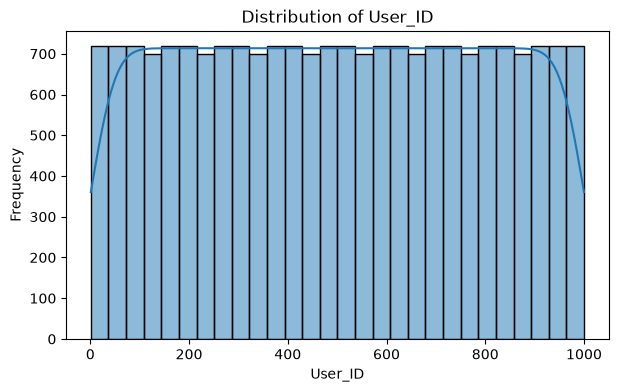

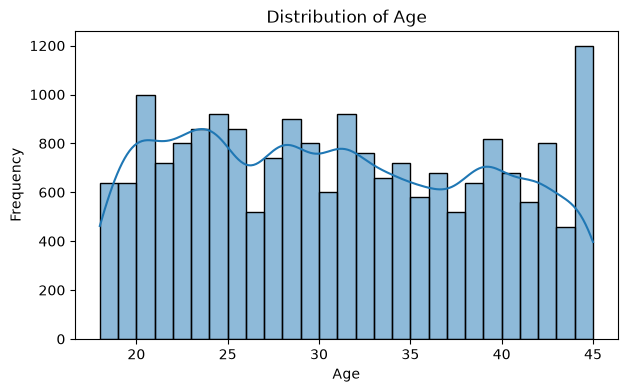

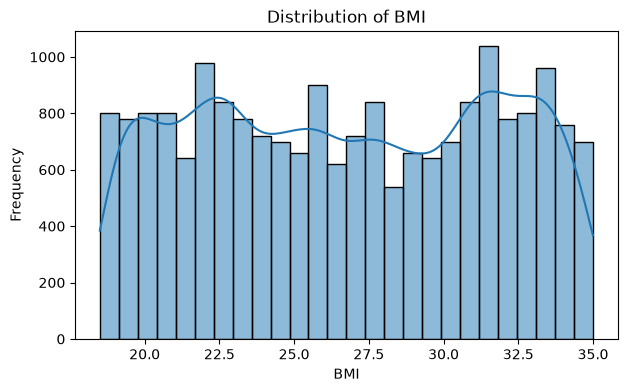

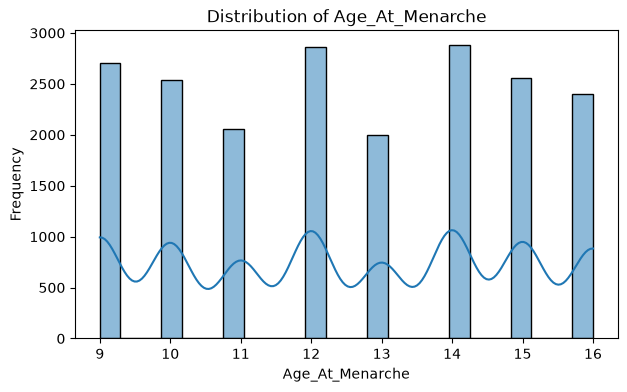

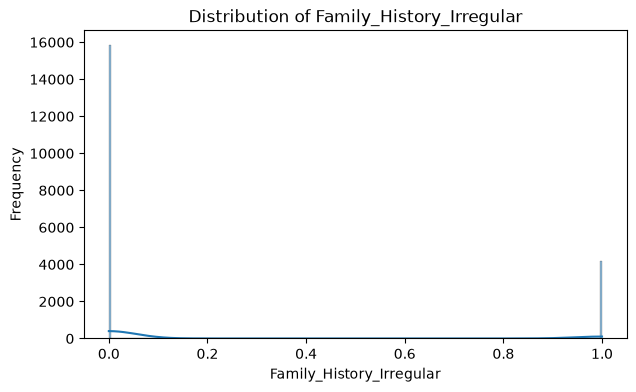

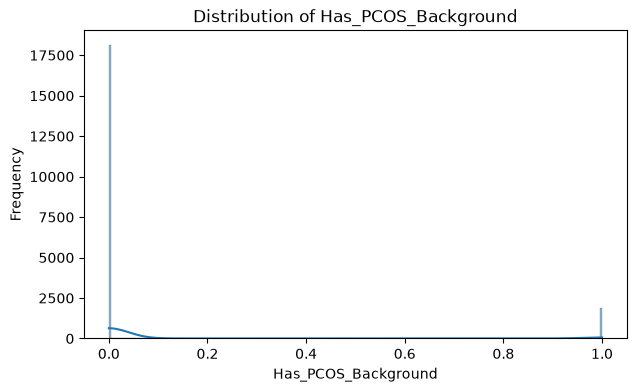

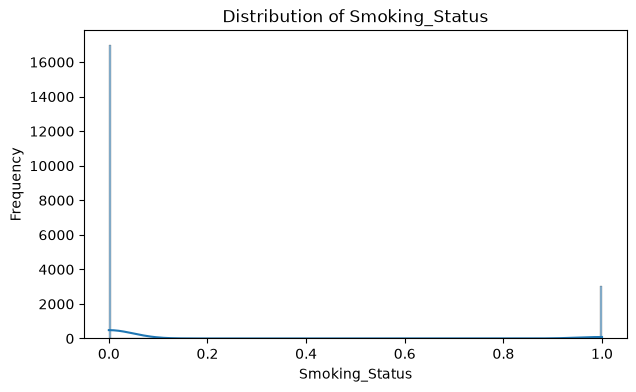

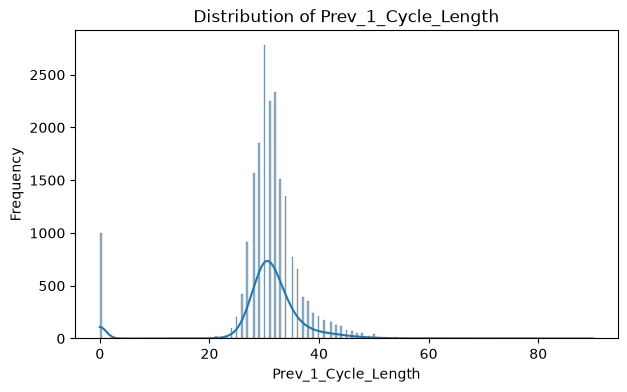

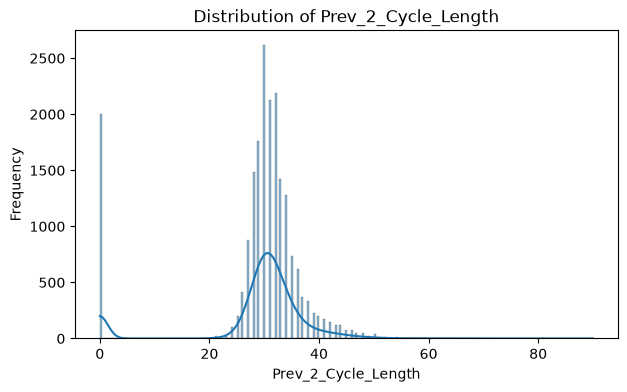

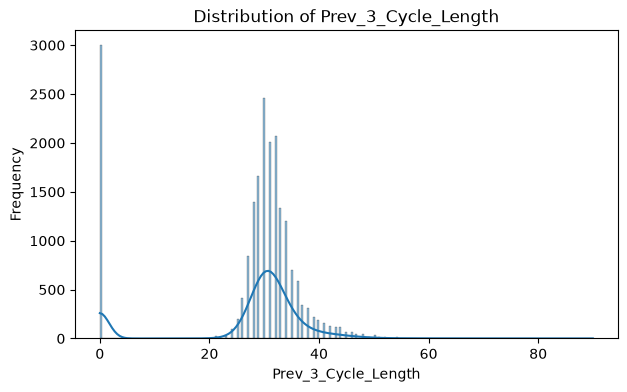

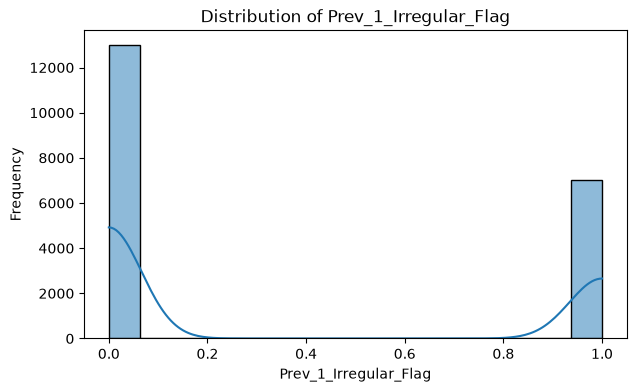

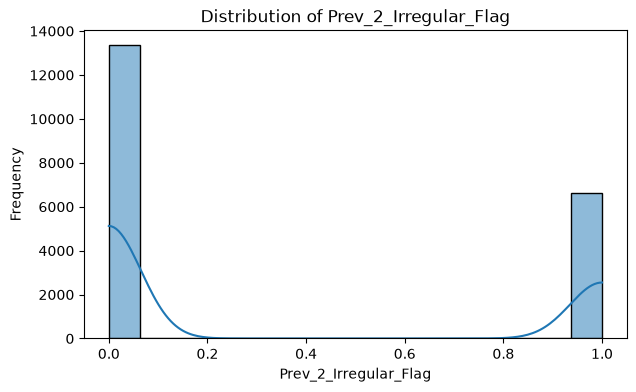

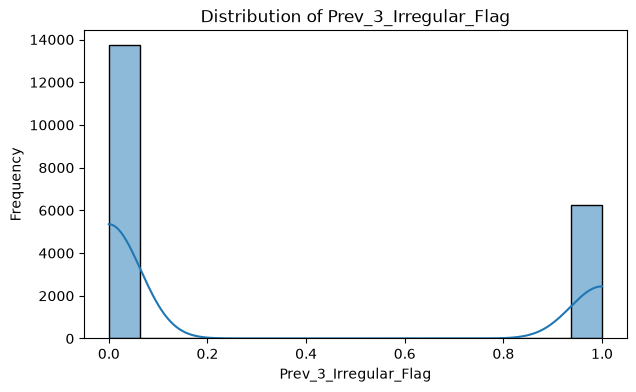

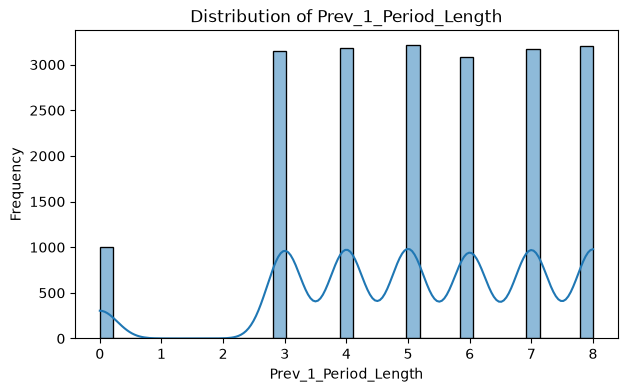

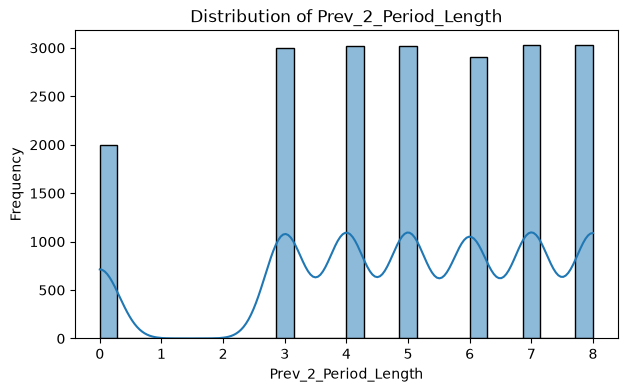

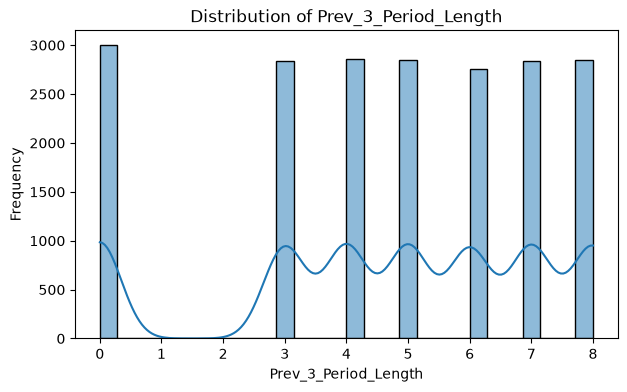

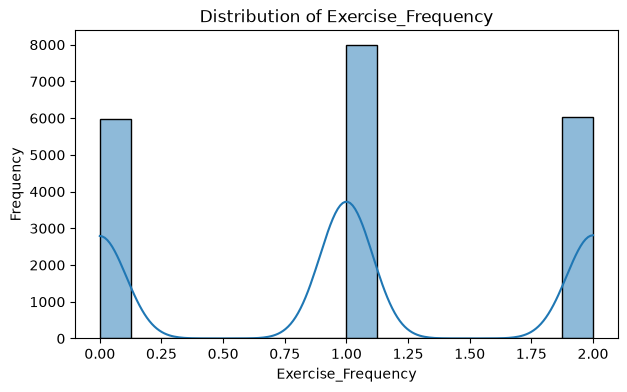

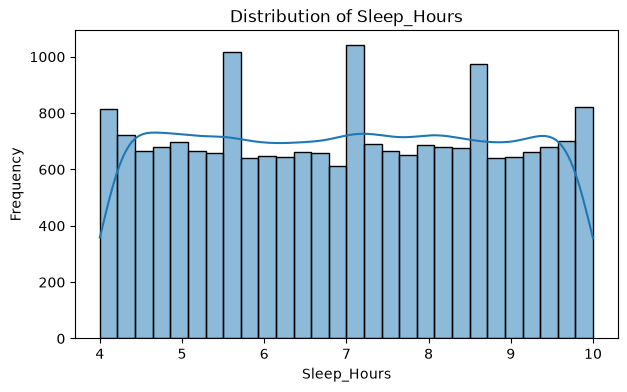

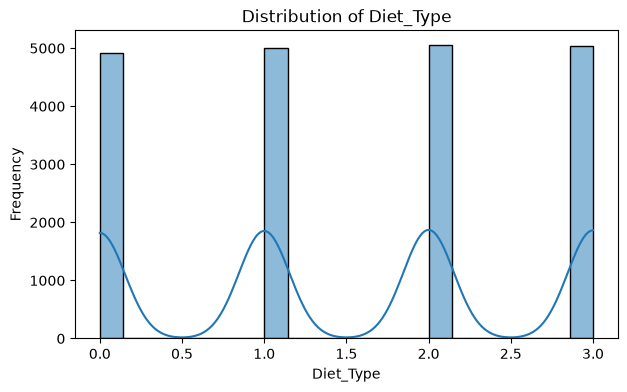

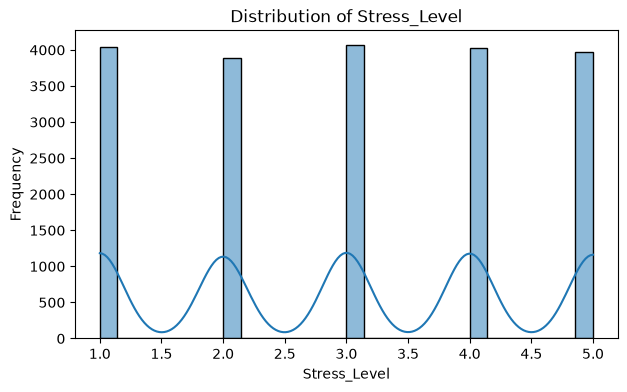

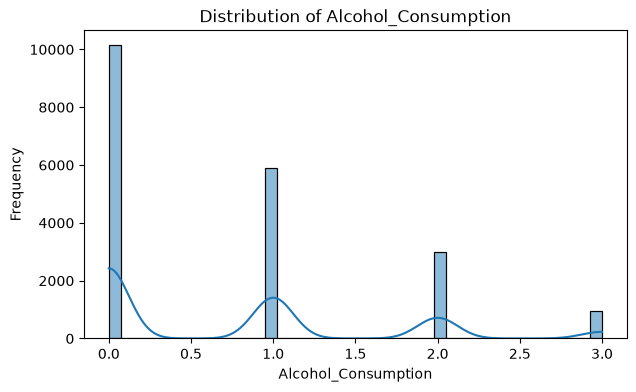

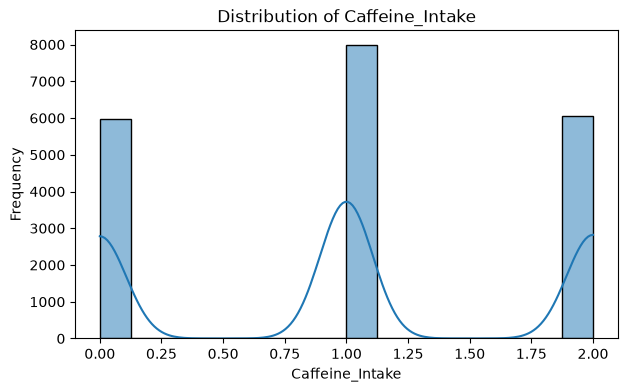

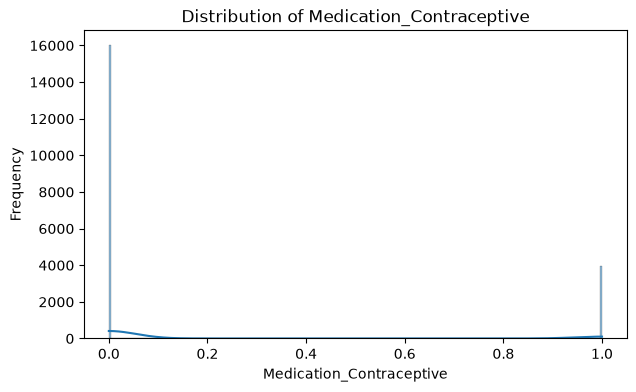

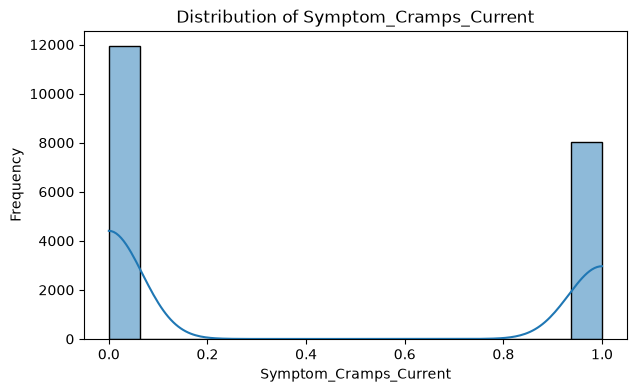

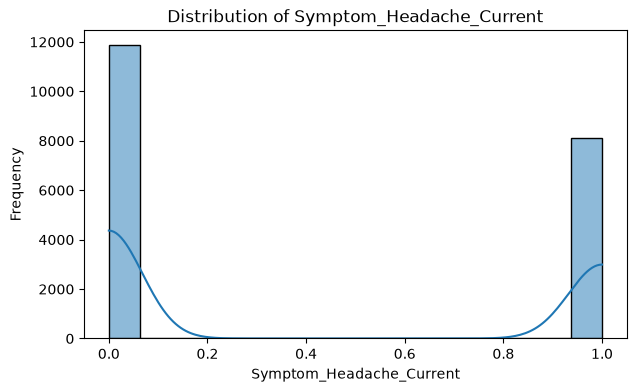

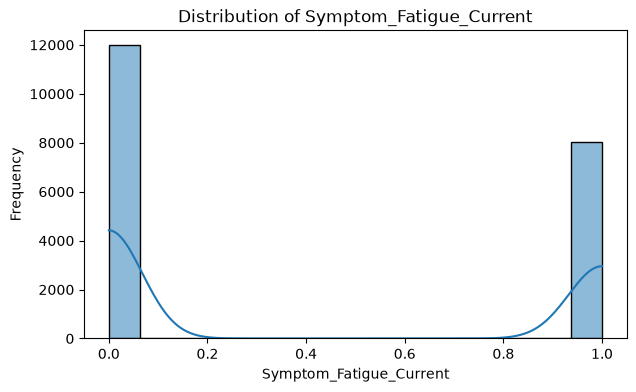

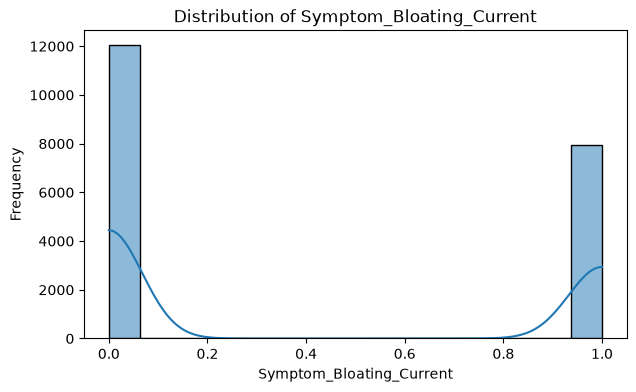

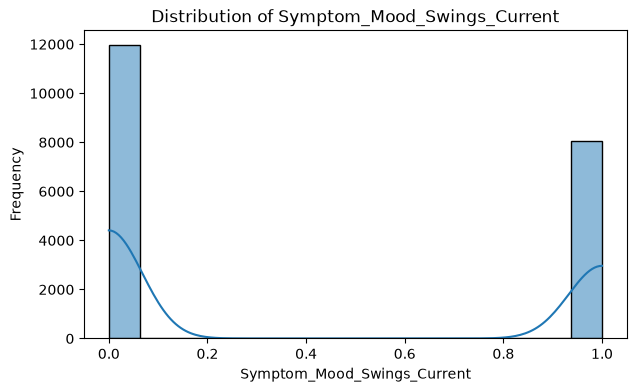

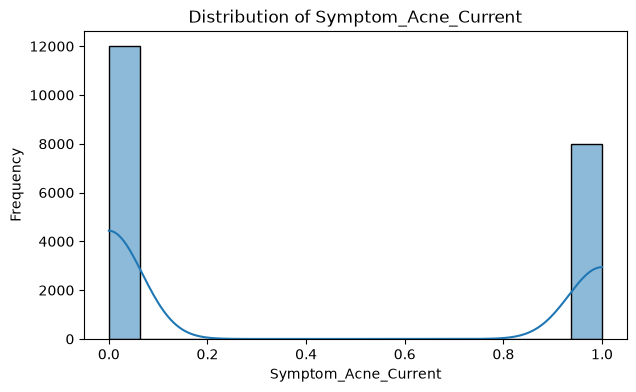

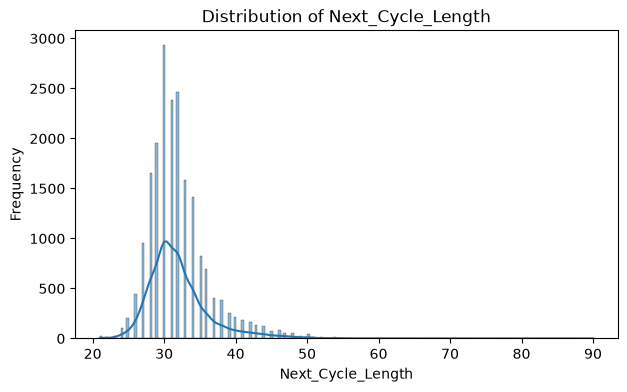

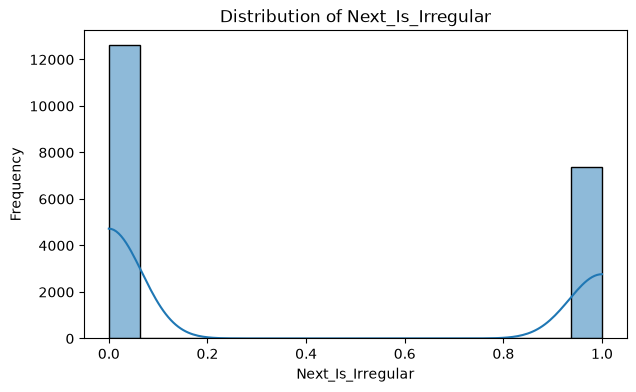

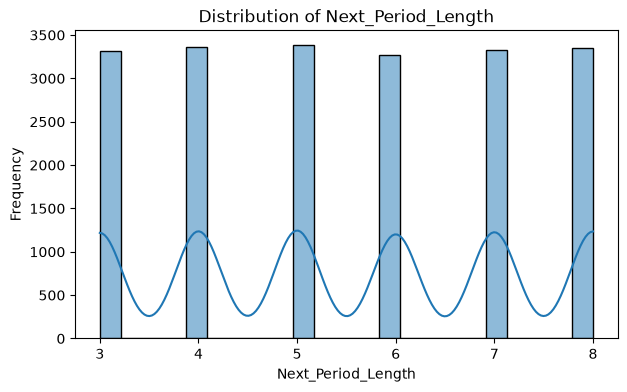

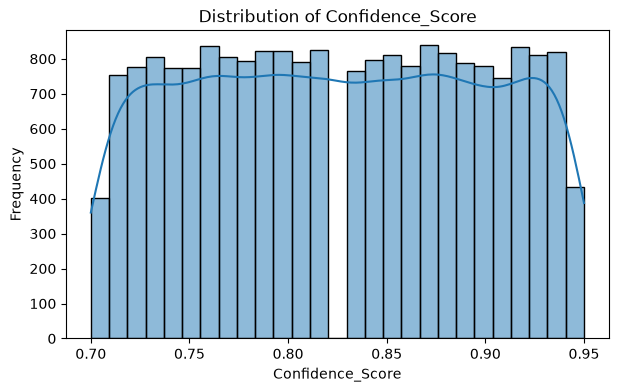

In [26]:
numerical_columns = kaggle_df.select_dtypes(include=["number"]).columns

for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(
        kaggle_df[column],
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

## Outlier Analysis

Boxplots are used to visually identify potential outliers in numerical features.



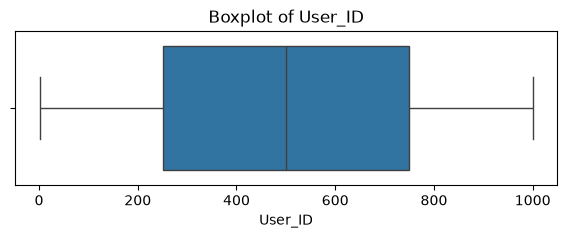

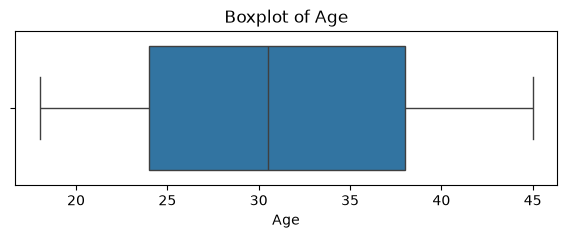

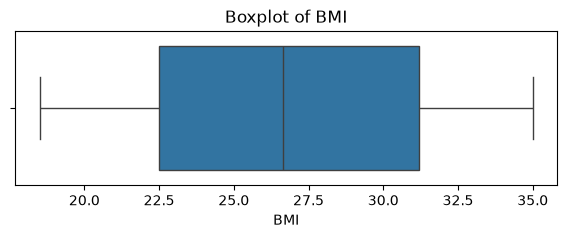

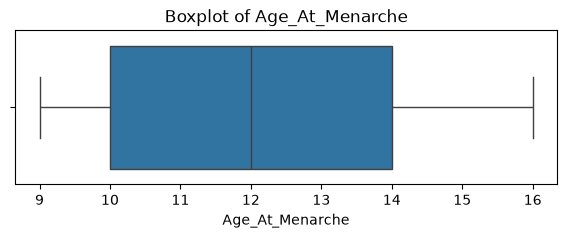

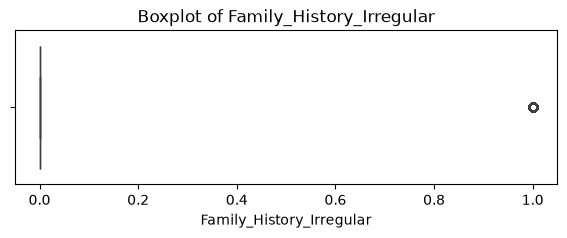

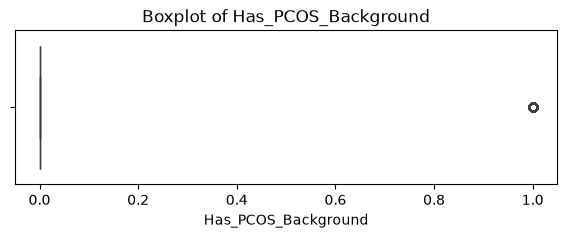

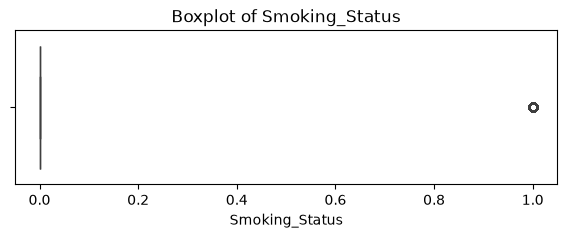

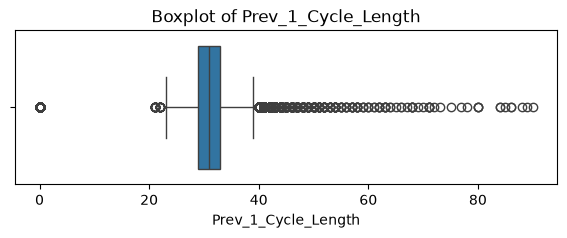

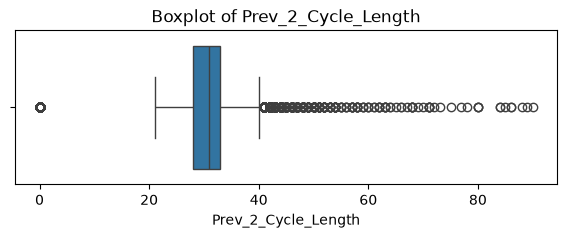

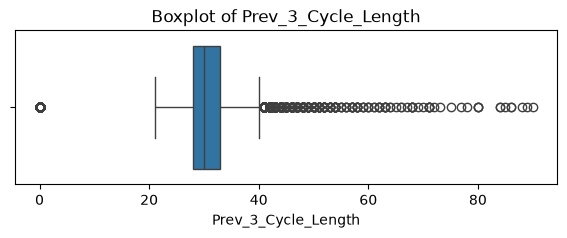

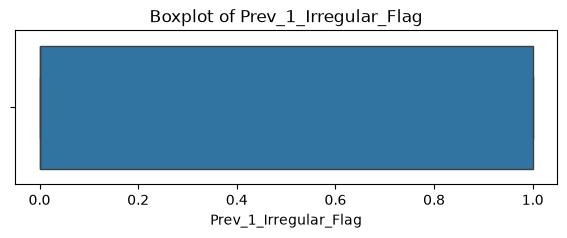

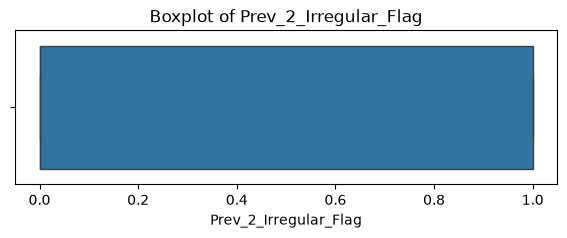

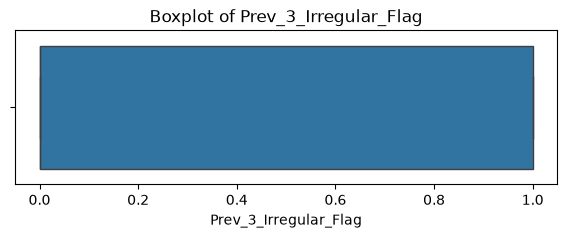

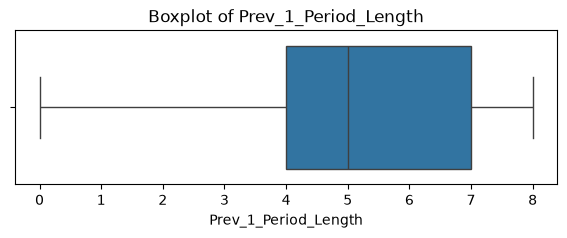

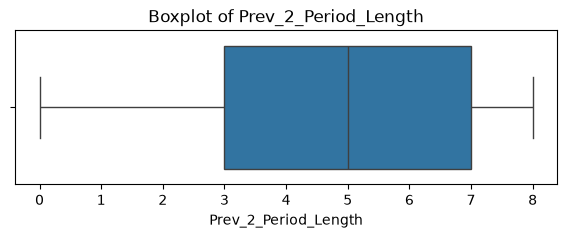

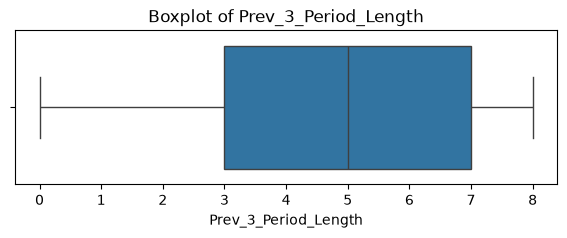

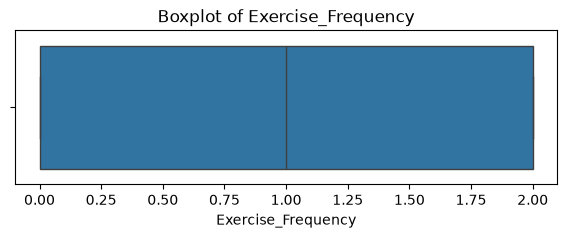

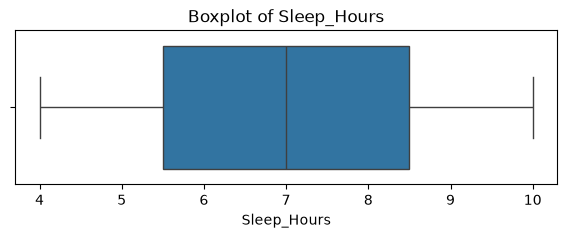

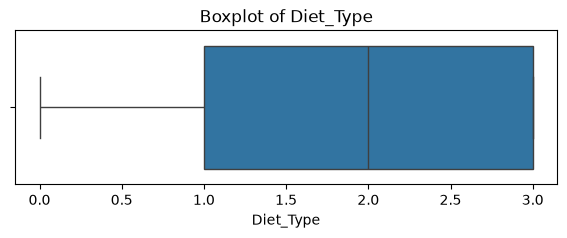

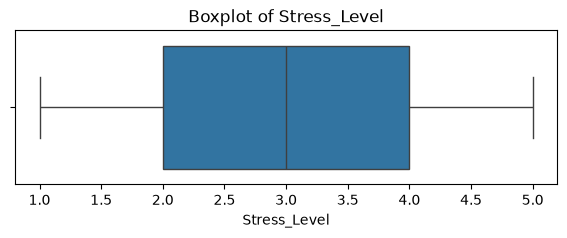

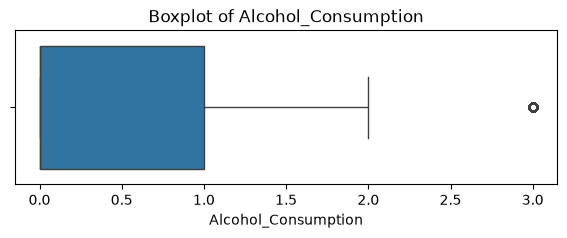

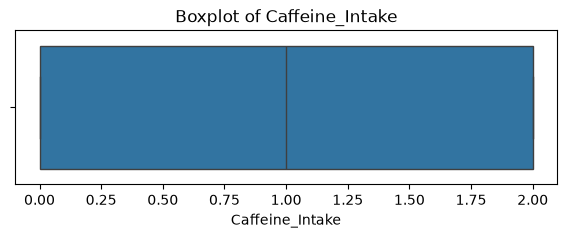

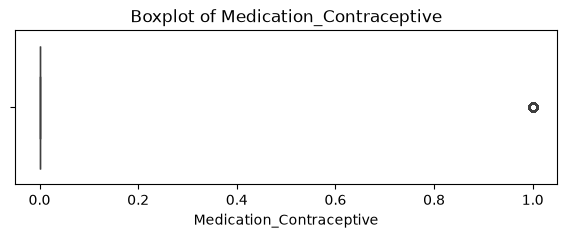

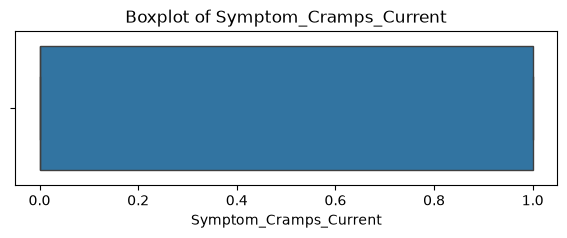

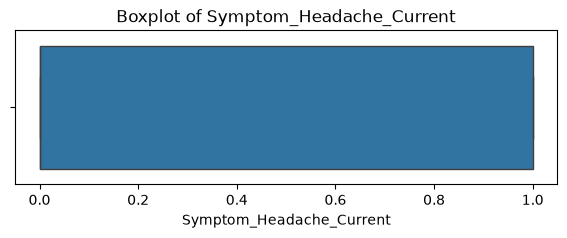

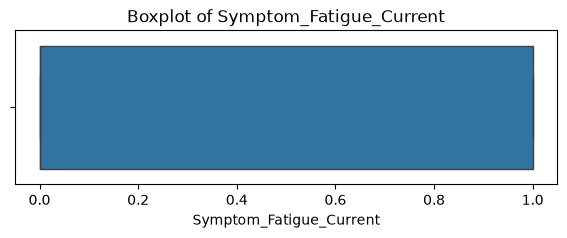

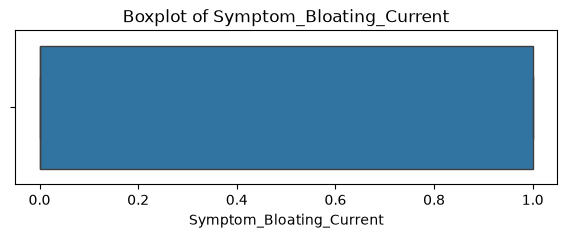

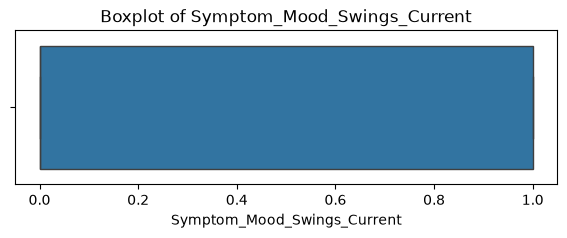

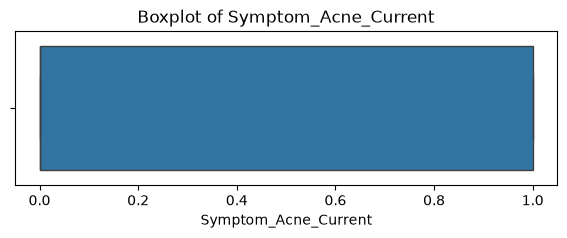

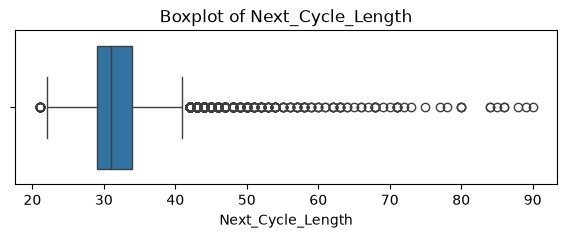

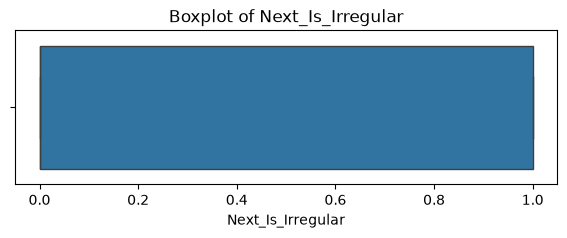

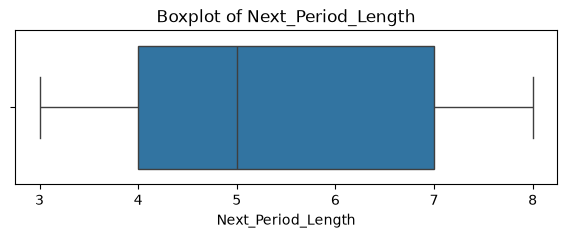

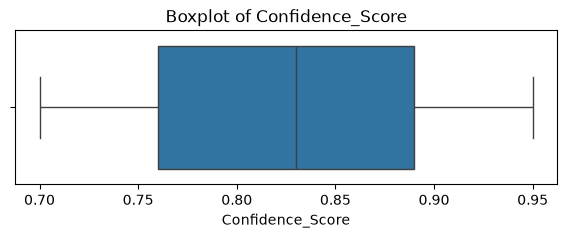

In [35]:
for column in numerical_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(
        x=kaggle_df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

# Survey Dataset Boxplots

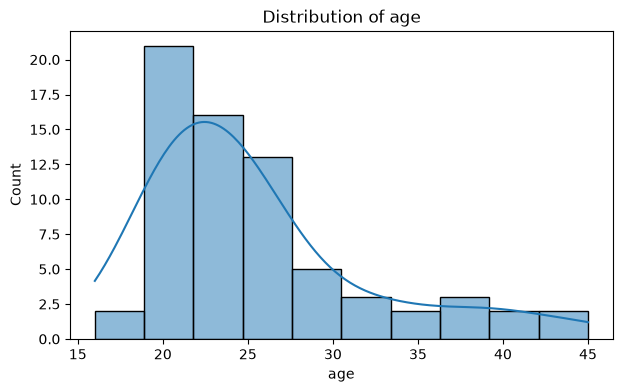

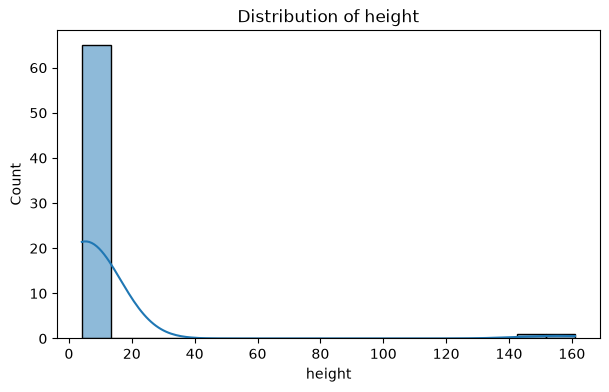

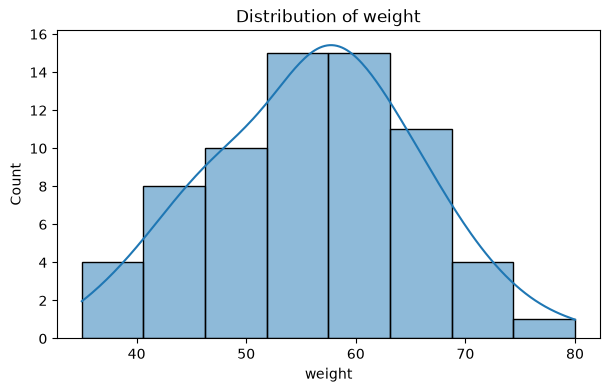

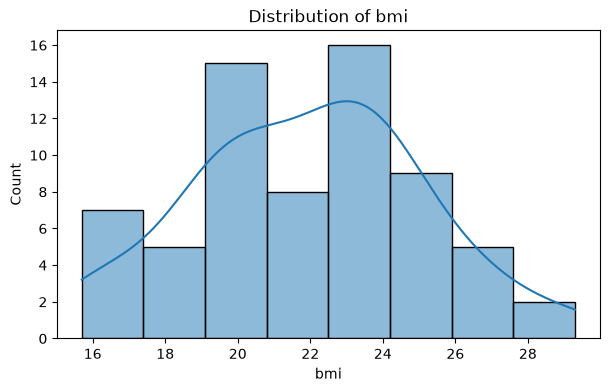

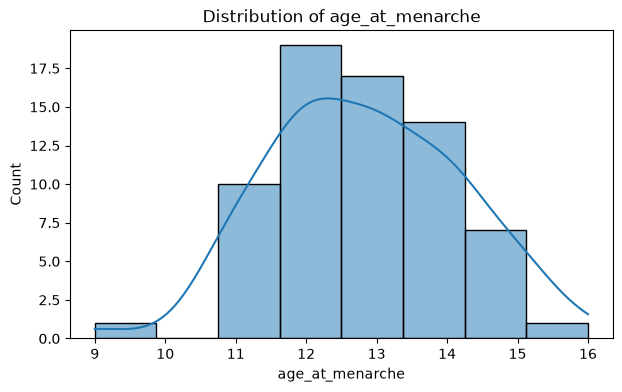

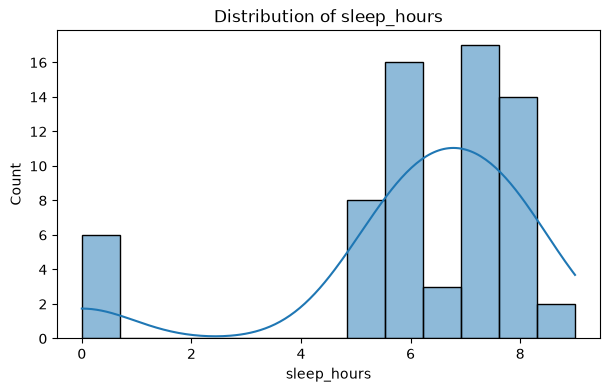

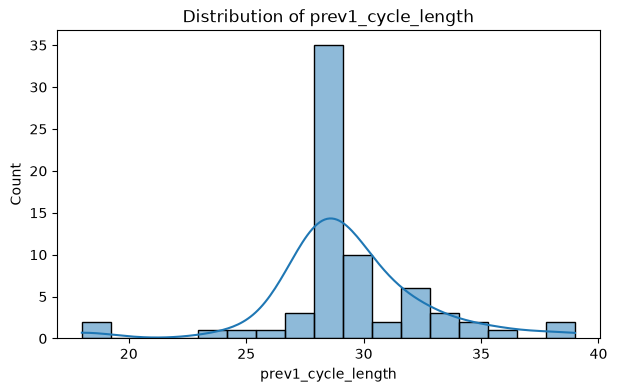

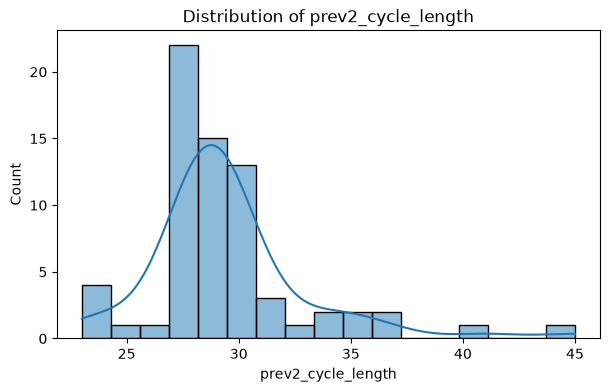

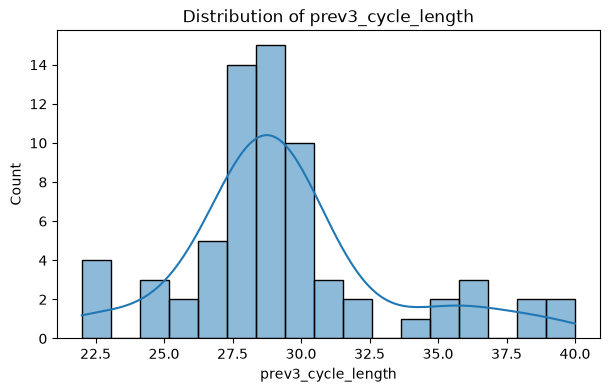

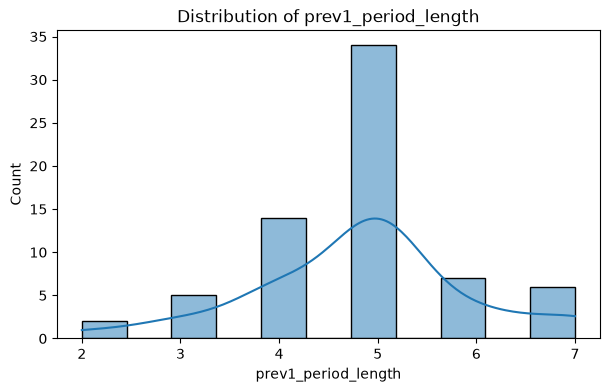

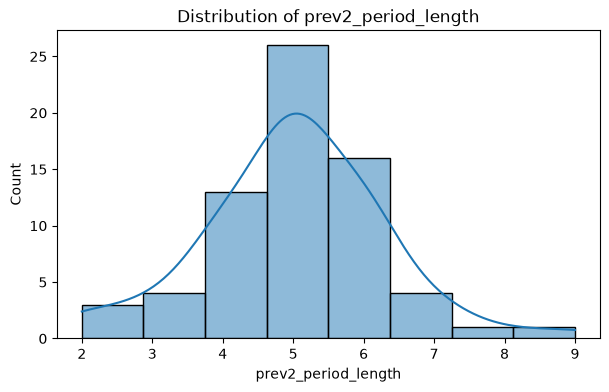

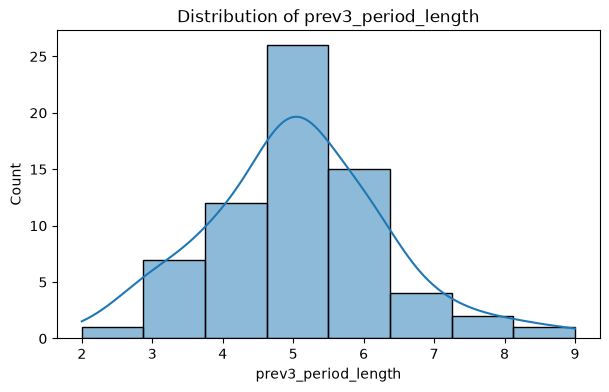

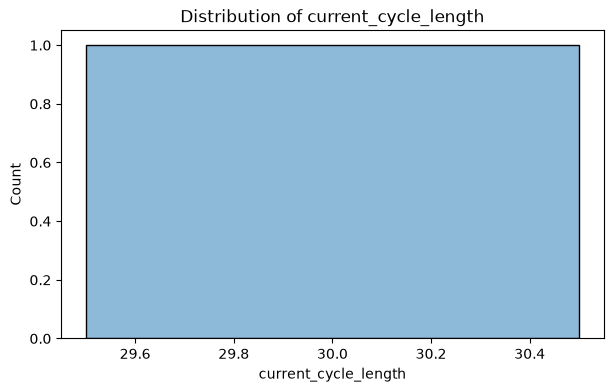

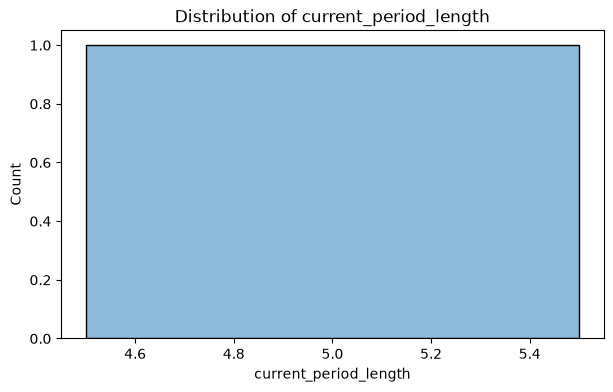

In [36]:
survey_numeric = survey_df.select_dtypes(include=["number"]).columns

for column in survey_numeric:

    plt.figure(figsize=(7,4))

    sns.histplot(
        survey_df[column],
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.show()

# Survey Dataset Feature Distribution

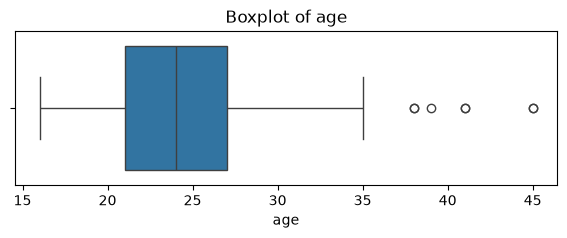

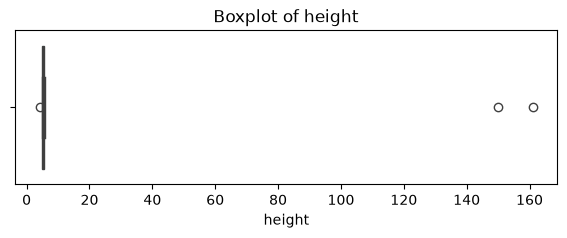

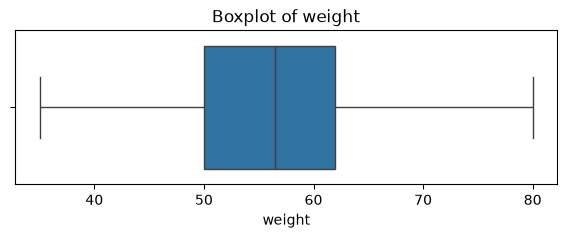

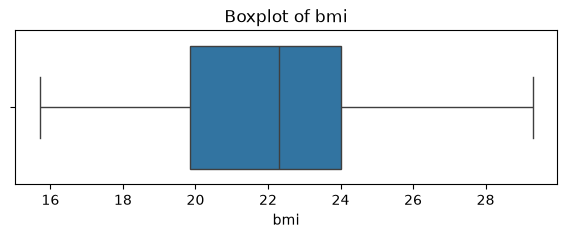

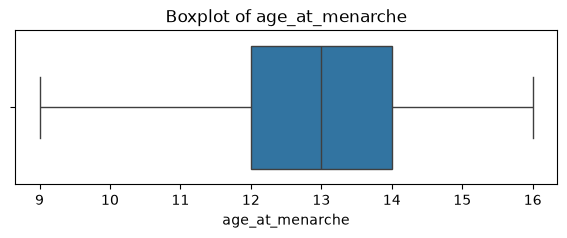

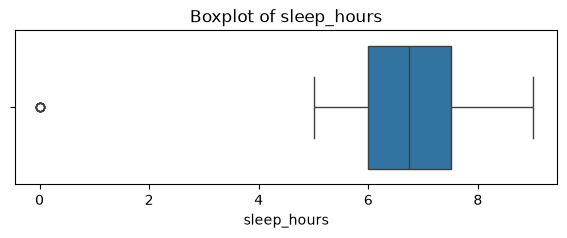

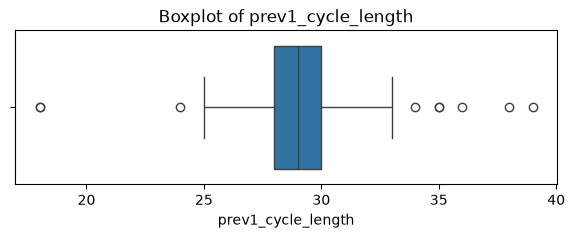

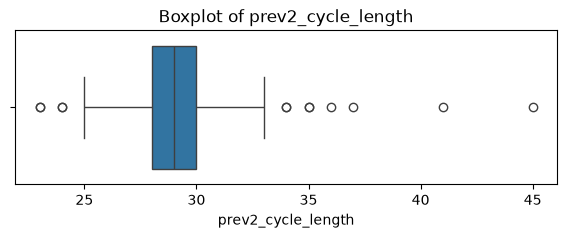

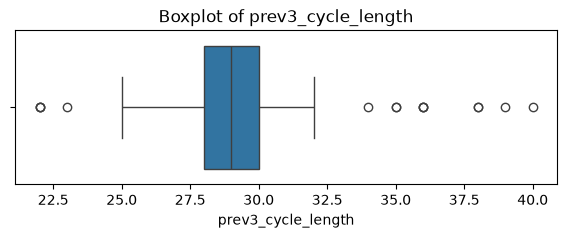

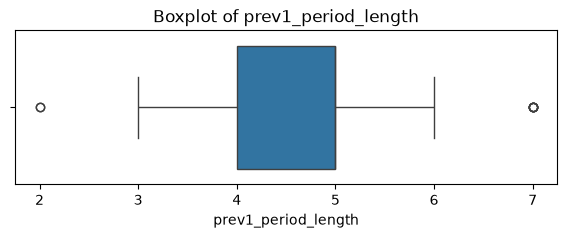

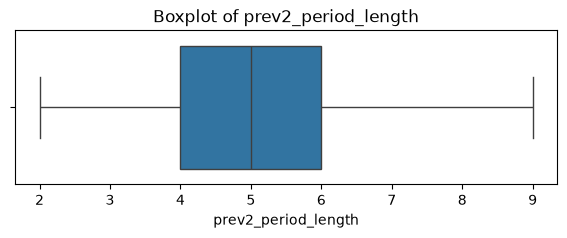

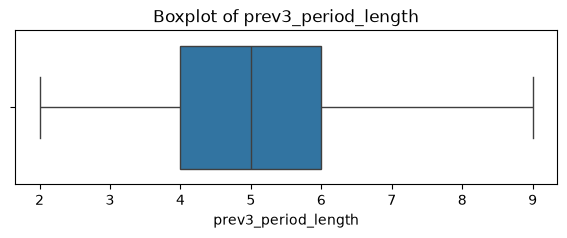

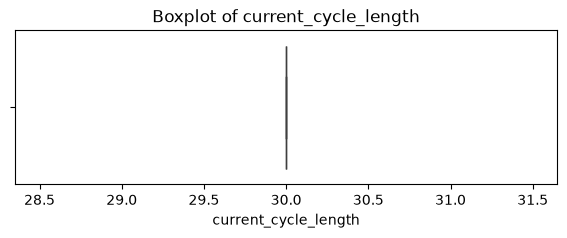

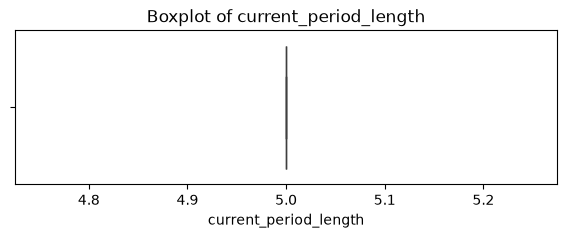

In [29]:
for column in survey_numeric:

    plt.figure(figsize=(7,2))

    sns.boxplot(
        x=survey_df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

## Conclusion

The two datasets serve different purposes within the project. The Kaggle dataset will be used for model development and training, while the survey dataset represents future user input for prediction.

Because the datasets originate from different sources and have different roles, they will **not** be merged. Instead, each dataset will undergo independent preprocessing while following the same methodology wherever applicable.

The observations obtained from this exploratory analysis provide the foundation for the preprocessing, feature engineering, model training, and deployment stages of the machine learning pipeline.